<a href="https://colab.research.google.com/github/CharishmaDonthamsetti/Analyzing-Molecular-Properties-Dataset-from-PubChem/blob/main/Analyzing_Molecular_Properties_Dataset_from_PubChem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

**Load the Dataset**

In [ ]:
import pandas as pd

url = "/content/SMILES_Big_Data_Set.csv"

df = pd.read_csv(url)
df.head()


,SMILES,pIC50,mol,num_atoms,logP
0,O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1cccs1,4.26,<rdkit.Chem.rdchem.Mol object at 0x7f59df45bc30>,25,4.1591
1,O=c1cc(-c2nc(-c3ccc(-c4cn(CCP(=O)(O)O)nn4)cc3)...,4.34,<rdkit.Chem.rdchem.Mol object at 0x7f59a320c9e0>,36,3.6743
2,NC(=O)c1ccc2c(c1)nc(C1CCC(O)CC1)n2CCCO,4.53,<rdkit.Chem.rdchem.Mol object at 0x7f59a320cac0>,23,1.5361
3,NCCCn1c(C2CCNCC2)nc2cc(C(N)=O)ccc21,4.56,<rdkit.Chem.rdchem.Mol object at 0x7f59a320cba0>,22,0.9510
4,CNC(=S)Nc1cccc(-c2cnc3ccccc3n2)c1,4.59,<rdkit.Chem.rdchem.Mol object at 0x7f59a320c7b0>,21,3.2130


Inspect the Data

In [ ]:
# View column names and data types
print(df.info())

# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16087 entries, 0 to 16086
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SMILES     16087 non-null  object 
 1   pIC50      15037 non-null  float64
 2   mol        16087 non-null  object 
 3   num_atoms  16087 non-null  int64  
 4   logP       16087 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 628.5+ KB
None

Missing Values:
 SMILES          0
pIC50        1050
mol             0
num_atoms       0
logP            0
dtype: int64


Basic Data Cleaning

In [ ]:
# Drop rows with missing values (if any)
df_clean = df.dropna()

# View cleaned dataset
df_clean


,SMILES,pIC50,mol,num_atoms,logP
0,O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1cccs1,4.26,<rdkit.Chem.rdchem.Mol object at 0x7f59df45bc30>,25,4.15910
1,O=c1cc(-c2nc(-c3ccc(-c4cn(CCP(=O)(O)O)nn4)cc3)...,4.34,<rdkit.Chem.rdchem.Mol object at 0x7f59a320c9e0>,36,3.67430
2,NC(=O)c1ccc2c(c1)nc(C1CCC(O)CC1)n2CCCO,4.53,<rdkit.Chem.rdchem.Mol object at 0x7f59a320cac0>,23,1.53610
3,NCCCn1c(C2CCNCC2)nc2cc(C(N)=O)ccc21,4.56,<rdkit.Chem.rdchem.Mol object at 0x7f59a320cba0>,22,0.95100
4,CNC(=S)Nc1cccc(-c2cnc3ccccc3n2)c1,4.59,<rdkit.Chem.rdchem.Mol object at 0x7f59a320c7b0>,21,3.21300
...,...,...,...,...,...
16082,S=C(NN=C(c1ccccn1)c1ccccn1)Nc1ccccc1,0.00,<rdkit.Chem.rdchem.Mol object at 0x7f59a314ed50>,24,3.21560
16083,S=C=NCCCCCCCCCCc1ccccc1,0.00,<rdkit.Chem.rdchem.Mol object at 0x7f59a314edc0>,19,5.45270
16084,S=C=NCCCCCCCCc1ccccc1,0.00,<rdkit.Chem.rdchem.Mol object at 0x7f59a314ee30>,17,4.67250
16085,S=c1[nH]nc(Cn2ccc3ccccc32)n1-c1ccccc1,0.00,<rdkit.Chem.rdchem.Mol object at 0x7f59a314eea0>,22,3.93289


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print(df.columns)

Index(['SMILES', 'pIC50', 'mol', 'num_atoms', 'logP'], dtype='object')


In [ ]:
df.columns = df.columns.str.strip().str.replace(" ", "")
print(df.columns)

Index(['SMILES', 'pIC50', 'mol', 'num_atoms', 'logP'], dtype='object')


In [ ]:
df_clean = df.dropna()

Visualize Property Trends

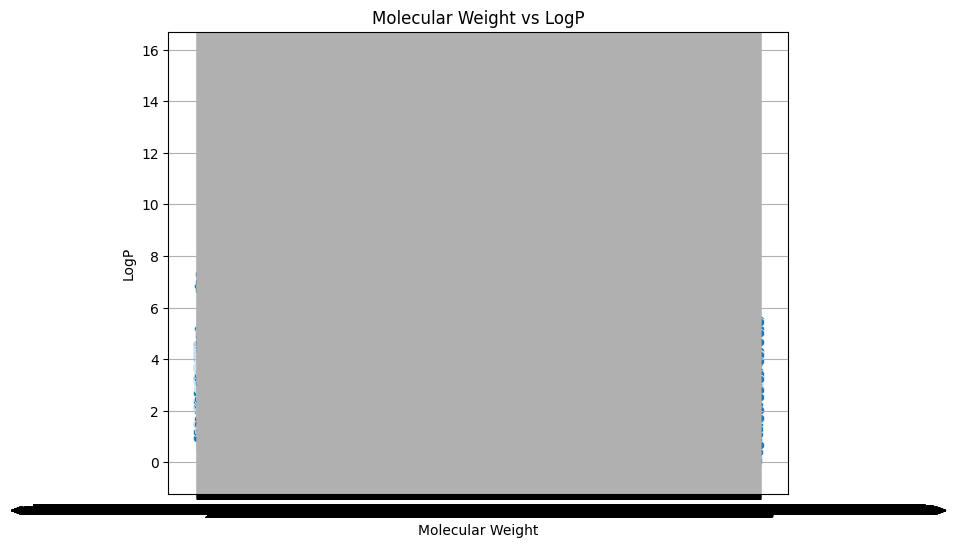

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='mol', y='logP', data=df_clean)
plt.title('Molecular Weight vs LogP')
plt.xlabel('Molecular Weight')
plt.ylabel('LogP')
plt.grid(True)
plt.show()


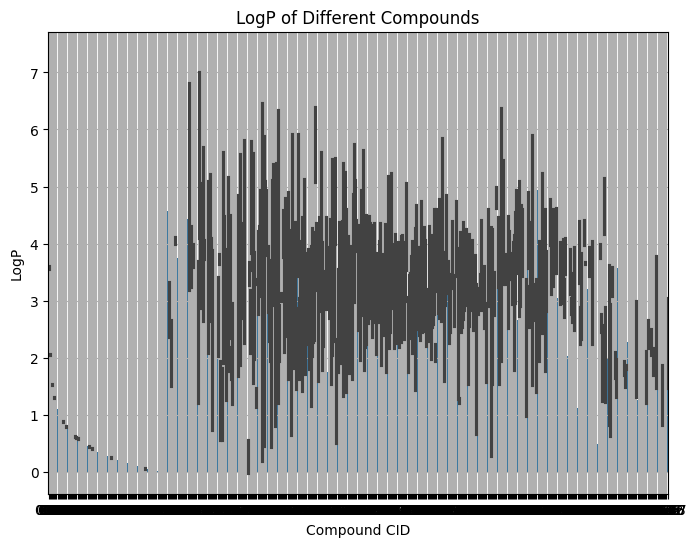

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(x='pIC50', y='logP', data=df_clean)
plt.title('LogP of Different Compounds')
plt.xlabel('Compound CID')
plt.ylabel('LogP')
plt.grid(True)
plt.show()

### Bonus: How These Trends Support Solvent Selection in Drug Development

- **Molecular Weight (MW)** influences solubility and permeability. Larger molecules may require solvents that can dissolve high-MW compounds.
- **LogP** (partition coefficient) indicates a compound's hydrophobicity. Compounds with high LogP are more lipid-soluble and require non-polar solvents for formulation.
- Analyzing the trend between MW and LogP helps in selecting the right solvent polarity during drug formulation to improve drug absorption and delivery.
v